In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_excel("final_health_data.xlsx")
df.head()

,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,is_Puducherry,is_Punjab,is_Rajasthan,is_Sikkim,is_Tamil Nadu,is_Telangana,is_Tripura,is_Uttar Pradesh,is_Uttarakhand,is_West Bengal
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,28,15-29,Female,5,...,0,0,0,0,0,0,0,0,0,0
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,47,45-59,Female,4,...,0,0,0,0,0,0,0,0,0,0
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,13,0-14,Female,3,...,0,0,0,0,0,0,0,0,0,0
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,53,45-59,Female,4,...,0,0,0,0,0,0,0,0,0,0
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,31,30-44,Male,6,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(df.dtypes)

# Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
print("\nNumerical columns:", list(numerical_cols))

record_id           object
state_or_ut         object
entity_type         object
district            object
district_name       object
                     ...  
is_Telangana         int64
is_Tripura           int64
is_Uttar Pradesh     int64
is_Uttarakhand       int64
is_West Bengal       int64
Length: 67, dtype: object

Numerical columns: ['age', 'household_size', 'chronic_disease', 'hypertension', 'diabetes', 'asthma', 'missed_visits_12m', 'missed_screenings_12m', 'days_since_last_visit', 'followup_delay_days', 'screening_completed', 'vaccination_up_to_date', 'facility_access_km', 'region_health_index', 'pgi', 'ill', 'obesity', 'is_City', 'is_Town', 'is_Village', 'is_Andaman and Nicobar Islands', 'is_Andhra Pradesh', 'is_Arunachal Pradesh', 'is_Assam', 'is_Bihar', 'is_Chandigarh', 'is_Chhattisgarh', 'is_Dadra and Nagar Haveli and Daman and Diu', 'is_Delhi', 'is_Goa', 'is_Gujarat', 'is_Haryana', 'is_Himachal Pradesh', 'is_Jammu and Kashmir', 'is_Jharkhand', 'is_Karnataka', 'is_Kerala

In [6]:
# Columns to scale (numerical ones from the specified list)
columns_to_scale = ['age', 'household_size', 'chronic_disease', 'hypertension', 'diabetes', 'asthma', 'missed_visits_12m', 'missed_screenings_12m', 'days_since_last_visit', 'followup_delay_days', 'screening_completed', 'vaccination_up_to_date', 'facility_access_km', 'region_health_index']

# Filter to ensure they are numerical
columns_to_scale = [col for col in columns_to_scale if col in numerical_cols]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("Scaled columns:", columns_to_scale)
print("Data scaled successfully.")

Scaled columns: ['age', 'household_size', 'chronic_disease', 'hypertension', 'diabetes', 'asthma', 'missed_visits_12m', 'missed_screenings_12m', 'days_since_last_visit', 'followup_delay_days', 'screening_completed', 'vaccination_up_to_date', 'facility_access_km', 'region_health_index']
Data scaled successfully.


In [7]:
df_scaled.head()

,record_id,state_or_ut,entity_type,district,district_name,locality_type,age,age_group,gender,household_size,...,is_Puducherry,is_Punjab,is_Rajasthan,is_Sikkim,is_Tamil Nadu,is_Telangana,is_Tripura,is_Uttar Pradesh,is_Uttarakhand,is_West Bengal
0,SYN-000001,Andhra Pradesh,State,ANDH-D08,Srikakulam,Village,-0.323802,15-29,Female,0.114536,...,0,0,0,0,0,0,0,0,0,0
1,SYN-000002,Andhra Pradesh,State,ANDH-D03,Guntur,Village,0.761615,45-59,Female,-0.524734,...,0,0,0,0,0,0,0,0,0,0
2,SYN-000003,Andhra Pradesh,State,ANDH-D06,Anantapur,Town,-1.180710,0-14,Female,-1.164005,...,0,0,0,0,0,0,0,0,0,0
3,SYN-000004,Andhra Pradesh,State,ANDH-D03,Guntur,Village,1.104379,45-59,Female,-0.524734,...,0,0,0,0,0,0,0,0,0,0
4,SYN-000005,Andhra Pradesh,State,ANDH-D06,Anantapur,Village,-0.152420,30-44,Male,0.753806,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Create separate dataframes for each state
# Columns to exclude
exclude_cols = ['state_or_ut', 'entity_type', 'district', 'district_name']

# Get unique states
states = df_scaled['state_or_ut'].unique()
print(f"Total states/UTs: {len(states)}")

# Get all is_ columns
is_columns = [col for col in df_scaled.columns if col.startswith('is_')]
print(f"Found {len(is_columns)} is_ columns\n")

# Create a dictionary to store all state dataframes
state_dfs = {}

for state in states:
    # Filter data for this state
    state_df = df_scaled[df_scaled['state_or_ut'] == state].drop(columns=exclude_cols)
    
    # Create variable name (replace spaces and special characters with underscore)
    var_name = 'df_' + state.replace(' ', '_').replace('and', '').replace('&', '').lower()
    
    # Determine which is_ column belongs to this state
    state_is_col = None
    for is_col in is_columns:
        # Check if this is_ column corresponds to the current state
        col_name = is_col.replace('is_', '').replace('_', ' ')
        if col_name.lower() == state.lower():
            state_is_col = is_col
            break
    
    # Drop all is_ columns except the one for this state
    cols_to_drop = [col for col in is_columns if col != state_is_col]
    state_df = state_df.drop(columns=cols_to_drop)
    
    # Assign to globals (this creates the variables like df_maharashtra, df_assam, etc.)
    globals()[var_name] = state_df
    state_dfs[var_name] = state_df
    
    print(f"{var_name}: {state_df.shape[0]} records, kept column: {state_is_col if state_is_col else 'None'}")

print(f"\nCreated {len(state_dfs)} state dataframes")

Total states/UTs: 36
Found 39 is_ columns

df_andhra_pradesh: 856 records, kept column: is_Andhra Pradesh
df_arunachal_pradesh: 298 records, kept column: is_Arunachal Pradesh
df_assam: 596 records, kept column: is_Assam
df_bihar: 1366 records, kept column: is_Bihar
df_chhattisgarh: 614 records, kept column: is_Chhattisgarh
df_goa: 387 records, kept column: is_Goa
df_gujarat: 1046 records, kept column: is_Gujarat
df_haryana: 612 records, kept column: is_Haryana
df_himachal_pradesh: 395 records, kept column: is_Himachal Pradesh
df_jharkh: 618 records, kept column: is_Jharkhand
df_karnataka: 1038 records, kept column: is_Karnataka
df_kerala: 609 records, kept column: is_Kerala
df_madhya_pradesh: 1134 records, kept column: is_Madhya Pradesh
df_maharashtra: 1537 records, kept column: is_Maharashtra
df_manipur: 309 records, kept column: is_Manipur
df_meghalaya: 310 records, kept column: is_Meghalaya
df_mizoram: 292 records, kept column: is_Mizoram
df_nagal: 289 records, kept column: is_Nagal

In [9]:
df_maharashtra.head()

,record_id,locality_type,age,age_group,gender,household_size,literacy_status,income_bracket,occupation_type,chronic_disease,...,days_since_last_visit,followup_delay_days,screening_completed,vaccination_up_to_date,facility_access_km,region_health_index,pgi,ill,obesity,is_Maharashtra
9569,SYN-009570,Town,0.190343,30-44,Male,1.393077,Literate,Middle,Student,-0.613630,...,-1.490684,-1.453820,0.965833,0.849363,-1.161553,1.259874,0.347,0,1,1
9570,SYN-009571,City,-0.666565,15-29,Female,-0.524734,Semi-literate,Lower-Middle,Student,1.629647,...,0.422951,0.430714,0.965833,0.849363,-1.478867,0.979708,0.699,1,1,1
9571,SYN-009572,Village,0.590234,30-44,Female,1.393077,Literate,Low,Farmer,1.629647,...,0.786541,0.830464,-1.035375,-1.177353,1.108458,0.637283,1.045,0,0,1
9572,SYN-009573,Town,-0.038166,30-44,Female,-0.524734,Illiterate,Middle,Student,-0.613630,...,-1.605502,-1.415748,0.965833,-1.177353,-1.088327,0.958955,0.594,0,0,1
9573,SYN-009574,Village,-1.923364,0-14,Male,1.393077,Literate,Lower-Middle,Salaried,-0.613630,...,-0.572139,-0.597213,0.965833,0.849363,0.449423,1.384392,0.287,0,0,1


In [10]:
# Statistical tests to find relationship with illness
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SSC
from scipy.stats import pointbiserialr, chi2_contingency

print("="*70)
print("STATISTICAL ANALYSIS: Finding Features Related to Illness")
print("="*70)

# Get the target variable 'ill'
if 'ill' in df_scaled.columns:
    target = df_scaled['ill']
    print(f"\nTarget variable 'ill' distribution:\n{target.value_counts()}\n")
    
    # Get numerical features (excluding 'ill' and other non-feature columns)
    features = df_scaled.select_dtypes(include=[np.number]).columns
    features = [col for col in features if col != 'ill']
    
    # 1. POINT-BISERIAL CORRELATION (best for continuous vs binary)
    print("="*70)
    print("1. POINT-BISERIAL CORRELATION (Continuous vs Binary Outcome)")
    print("="*70)
    correlations = []
    for feature in features:
        corr, p_value = pointbiserialr(target, df_scaled[feature])
        correlations.append({
            'Feature': feature,
            'Correlation': corr,
            'P-Value': p_value,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })
    
    corr_df = pd.DataFrame(correlations).sort_values('Correlation', key=abs, ascending=False)
    print(corr_df.head(15).to_string(index=False))
    
    # 2. INDEPENDENT T-TESTS (compare ill vs not ill groups)
    print("\n" + "="*70)
    print("2. INDEPENDENT T-TESTS (Ill vs Not Ill Groups)")
    print("="*70)
    t_tests = []
    for feature in features:
        ill_group = df_scaled[target == 1][feature].dropna()
        not_ill_group = df_scaled[target == 0][feature].dropna()
        
        t_stat, p_value = stats.ttest_ind(ill_group, not_ill_group)
        
        # Calculate Cohen's d (effect size)
        mean_diff = ill_group.mean() - not_ill_group.mean()
        pooled_std = np.sqrt((ill_group.std()**2 + not_ill_group.std()**2) / 2)
        cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0
        
        t_tests.append({
            'Feature': feature,
            'T-Statistic': t_stat,
            'P-Value': p_value,
            'Mean_Ill': ill_group.mean(),
            'Mean_NotIll': not_ill_group.mean(),
            'Cohens_d': cohens_d,
            'Significant': 'Yes' if p_value < 0.05 else 'No'
        })
    
    t_test_df = pd.DataFrame(t_tests).sort_values('Cohens_d', key=abs, ascending=False)
    print(t_test_df[['Feature', 'T-Statistic', 'P-Value', 'Cohens_d', 'Significant']].head(15).to_string(index=False))
    
    # 3. LOGISTIC REGRESSION (feature importance)
    print("\n" + "="*70)
    print("3. LOGISTIC REGRESSION (Feature Coefficients - Importance)")
    print("="*70)
    X = df_scaled[features].fillna(df_scaled[features].mean())
    y = target
    
    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X, y)
    
    log_reg_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': log_reg.coef_[0],
        'Abs_Coefficient': np.abs(log_reg.coef_[0])
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print(log_reg_df.head(15).to_string(index=False))
    print(f"\nLogistic Regression R² Score: {log_reg.score(X, y):.4f}")
    
    print("\n" + "="*70)
    print("SUMMARY: Top 10 Features Most Related to Illness")
    print("="*70)
    top_features = corr_df.head(10)[['Feature', 'Correlation', 'P-Value']]
    print(top_features.to_string(index=False))
    
else:
    print("\n'ill' column not found in df_scaled")

STATISTICAL ANALYSIS: Finding Features Related to Illness

Target variable 'ill' distribution:
ill
1    15814
0     8186
Name: count, dtype: int64

1. POINT-BISERIAL CORRELATION (Continuous vs Binary Outcome)
               Feature  Correlation       P-Value Significant
               obesity     0.575048  0.000000e+00         Yes
                   pgi     0.484861  0.000000e+00         Yes
     missed_visits_12m     0.394436  0.000000e+00         Yes
 missed_screenings_12m     0.349462  0.000000e+00         Yes
   region_health_index    -0.296022  0.000000e+00         Yes
 days_since_last_visit     0.282832  0.000000e+00         Yes
   followup_delay_days     0.281926  0.000000e+00         Yes
       chronic_disease     0.279817  0.000000e+00         Yes
          hypertension     0.241614 7.521001e-316         Yes
                   age     0.234388 7.790869e-297         Yes
              diabetes     0.222520 5.340662e-267         Yes
            is_Village     0.069546  3.982707e-

In [11]:
# ============================================================================
# FILTER SIGNIFICANT FEATURES AND TRAIN MULTIPLE MODELS
# ============================================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression

print("="*80)
print("STEP 1: FILTERING SIGNIFICANT FEATURES FROM T-TESTS")
print("="*80)

# Get significant features (p-value < 0.05)
significant_features = t_test_df[t_test_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"\nTotal significant features (p < 0.05): {len(significant_features)}")
print(f"Significant features: {significant_features}\n")

# Prepare data with only significant features
X_significant = df_scaled[significant_features].fillna(df_scaled[significant_features].mean())
y = df_scaled['ill']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_significant, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Class distribution - Training set:\n{y_train.value_counts()}\n")

# ============================================================================
# STEP 2: TRAIN MULTIPLE MODELS
# ============================================================================

print("="*80)
print("STEP 2: TRAINING MULTIPLE MODELS AND EVALUATING PERFORMANCE")
print("="*80)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
}

model_results = []
trained_models = {}

for model_name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    model_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(model_results).sort_values('Accuracy', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON (Sorted by Accuracy)")
print("="*80)
print(results_df.to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"\n✓ Best Model: {best_model_name} with Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")


STEP 1: FILTERING SIGNIFICANT FEATURES FROM T-TESTS

Total significant features (p < 0.05): 19
Significant features: ['obesity', 'pgi', 'missed_visits_12m', 'missed_screenings_12m', 'region_health_index', 'chronic_disease', 'days_since_last_visit', 'followup_delay_days', 'hypertension', 'diabetes', 'age', 'is_Village', 'is_City', 'facility_access_km', 'vaccination_up_to_date', 'is_Town', 'is_Punjab', 'screening_completed', 'is_Jammu and Kashmir']

Training set size: 19200
Test set size: 4800
Class distribution - Training set:
ill
1    12651
0     6549
Name: count, dtype: int64

STEP 2: TRAINING MULTIPLE MODELS AND EVALUATING PERFORMANCE

Logistic Regression:
  Accuracy:  0.9823
  Precision: 0.9818
  Recall:    0.9915
  F1-Score:  0.9866

K-Nearest Neighbors:
  Accuracy:  0.9569
  Precision: 0.9584
  Recall:    0.9769
  F1-Score:  0.9676

Decision Tree:
  Accuracy:  0.9869
  Precision: 0.9890
  Recall:    0.9911
  F1-Score:  0.9901

Random Forest:
  Accuracy:  0.9902
  Precision: 0.9930

In [12]:
# ============================================================================
# STEP 3: PREDICT RISK FOR EACH STATE (0-100%)
# ============================================================================

print("\n" + "="*80)
print("STEP 3: STATE-WISE ILLNESS RISK PREDICTIONS")
print("="*80)

# Use the best model for predictions
print(f"\nUsing {best_model_name} for state predictions\n")

# Get all states
all_states = df_scaled['state_or_ut'].unique()
state_predictions = []

for state in sorted(all_states):
    # Get state data
    state_data = df_scaled[df_scaled['state_or_ut'] == state][significant_features]
    state_data = state_data.fillna(state_data.mean())
    
    if len(state_data) > 0:
        # Get predictions and probabilities
        risk_probs = best_model.predict_proba(state_data)[:, 1]
        avg_risk = risk_probs.mean()
        
        # Convert to percentage and check if ill
        risk_percentage = avg_risk * 100
        is_ill = "ILL (Risk > 50%)" if avg_risk > 0.5 else "HEALTHY (Risk ≤ 50%)"
        
        state_predictions.append({
            'State': state,
            'Sample_Count': len(state_data),
            'Avg_Risk_Probability': avg_risk,
            'Risk_Percentage': risk_percentage,
            'Status': is_ill,
            'Max_Risk': risk_probs.max(),
            'Min_Risk': risk_probs.min()
        })

# Create predictions dataframe
predictions_df = pd.DataFrame(state_predictions)
predictions_df = predictions_df.sort_values('Avg_Risk_Probability', ascending=False)

print("STATE-WISE ILLNESS RISK ASSESSMENT\n")
print("Legend: Risk < 50% = HEALTHY | Risk ≥ 50% = ILL\n")
print(predictions_df.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
high_risk_states = predictions_df[predictions_df['Avg_Risk_Probability'] > 0.5]
low_risk_states = predictions_df[predictions_df['Avg_Risk_Probability'] <= 0.5]

print(f"\nHigh-Risk States (Risk > 50%): {len(high_risk_states)}")
if len(high_risk_states) > 0:
    print(high_risk_states[['State', 'Risk_Percentage']].to_string(index=False))

print(f"\nLow-Risk States (Risk ≤ 50%): {len(low_risk_states)}")
if len(low_risk_states) > 0:
    print(low_risk_states[['State', 'Risk_Percentage']].head(10).to_string(index=False))

print(f"\nOverall Statistics:")
print(f"  Mean Risk Across States: {predictions_df['Avg_Risk_Probability'].mean()*100:.2f}%")
print(f"  Max Risk: {predictions_df['Avg_Risk_Probability'].max()*100:.2f}% ({predictions_df.loc[predictions_df['Avg_Risk_Probability'].idxmax(), 'State']})")
print(f"  Min Risk: {predictions_df['Avg_Risk_Probability'].min()*100:.2f}% ({predictions_df.loc[predictions_df['Avg_Risk_Probability'].idxmin(), 'State']})")


STEP 3: STATE-WISE ILLNESS RISK PREDICTIONS

Using Random Forest for state predictions

STATE-WISE ILLNESS RISK ASSESSMENT

Legend: Risk < 50% = HEALTHY | Risk ≥ 50% = ILL

                                   State  Sample_Count  Avg_Risk_Probability  Risk_Percentage           Status  Max_Risk  Min_Risk
                                  Sikkim           295              0.705175        70.517488 ILL (Risk > 50%)       1.0  0.000641
Dadra and Nagar Haveli and Daman and Diu           303              0.704999        70.499914 ILL (Risk > 50%)       1.0  0.000480
                       Jammu and Kashmir           509              0.698002        69.800234 ILL (Risk > 50%)       1.0  0.000483
                                 Tripura           314              0.697546        69.754602 ILL (Risk > 50%)       1.0  0.000714
                             Uttarakhand           502              0.696232        69.623194 ILL (Risk > 50%)       1.0  0.000803
                                 Manipur

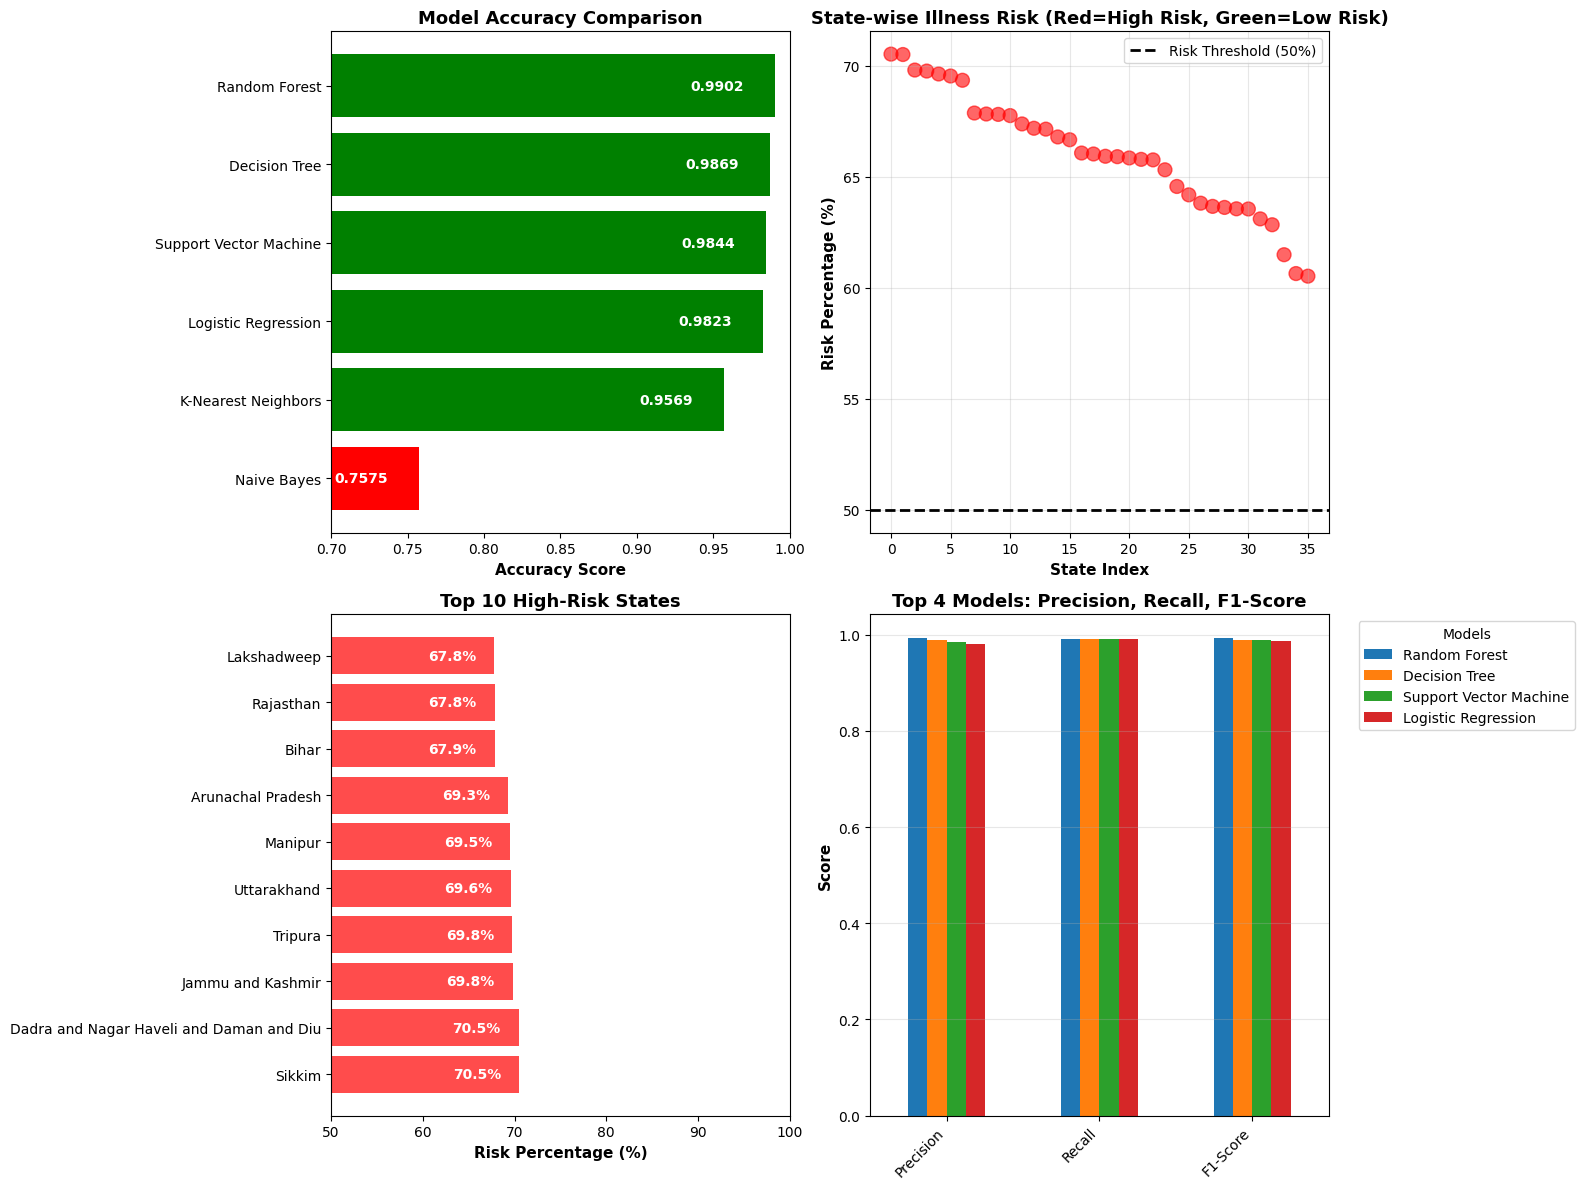


Visualization complete!


In [13]:
# Visualization of Model Performance
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model Accuracy Comparison
ax1 = axes[0, 0]
models_sorted = results_df.sort_values('Accuracy', ascending=True)
colors_acc = ['green' if x > 0.95 else 'orange' if x > 0.85 else 'red' for x in models_sorted['Accuracy']]
ax1.barh(models_sorted['Model'], models_sorted['Accuracy'], color=colors_acc)
ax1.set_xlabel('Accuracy Score', fontsize=11, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_xlim([0.7, 1.0])
for i, v in enumerate(models_sorted['Accuracy']):
    ax1.text(v - 0.02, i, f'{v:.4f}', va='center', ha='right', fontweight='bold', color='white')

# 2. State Risk Distribution
ax2 = axes[0, 1]
colors_risk = ['red' if x > 0.5 else 'green' for x in predictions_df['Avg_Risk_Probability']]
ax2.scatter(range(len(predictions_df)), predictions_df['Avg_Risk_Probability']*100, c=colors_risk, s=100, alpha=0.6)
ax2.axhline(y=50, color='black', linestyle='--', linewidth=2, label='Risk Threshold (50%)')
ax2.set_xlabel('State Index', fontsize=11, fontweight='bold')
ax2.set_ylabel('Risk Percentage (%)', fontsize=11, fontweight='bold')
ax2.set_title('State-wise Illness Risk (Red=High Risk, Green=Low Risk)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. High-Risk States
ax3 = axes[1, 0]
high_risk = predictions_df[predictions_df['Avg_Risk_Probability'] > 0.5].head(10)
if len(high_risk) > 0:
    ax3.barh(high_risk['State'], high_risk['Risk_Percentage'], color='red', alpha=0.7)
    ax3.set_xlabel('Risk Percentage (%)', fontsize=11, fontweight='bold')
    ax3.set_title('Top 10 High-Risk States', fontsize=13, fontweight='bold')
    ax3.set_xlim([50, 100])
    for i, v in enumerate(high_risk['Risk_Percentage']):
        ax3.text(v - 2, i, f'{v:.1f}%', va='center', ha='right', fontweight='bold', color='white')
else:
    ax3.text(0.5, 0.5, 'No High-Risk States', ha='center', va='center', fontsize=12)

# 4. Model Metrics Comparison
ax4 = axes[1, 1]
data_to_plot = results_df[['Precision', 'Recall', 'F1-Score']].head(4).T
data_to_plot.columns = results_df['Model'].head(4).values
data_to_plot.plot(kind='bar', ax=ax4, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Top 4 Models: Precision, Recall, F1-Score', fontsize=13, fontweight='bold')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [14]:
# ============================================================================
# STEP 4: DISTRICT-LEVEL ANALYSIS FOR EACH STATE
# ============================================================================

print("\n" + "="*80)
print("STEP 4: DISTRICT-WISE ILLNESS RISK PREDICTIONS")
print("="*80)

# We need to get district information from original df (before dropping it)
# Create a mapping of state -> districts from original data
state_district_map = df.groupby('state_or_ut')['district_name'].unique().to_dict()

district_predictions = []

# For each state, get districts and make predictions
for state in sorted(all_states):
    print(f"\n{'='*80}")
    print(f"STATE: {state}")
    print(f"{'='*80}")
    
    # Get the original data for this state to have district info
    state_original_data = df[df['state_or_ut'] == state].copy()
    
    # Get unique districts in this state
    unique_districts = state_original_data['district_name'].unique()
    print(f"Districts in {state}: {len(unique_districts)}\n")
    
    state_district_results = []
    
    for district in sorted(unique_districts):
        # Get data for this district from original df
        district_original = state_original_data[state_original_data['district_name'] == district]
        
        # Get corresponding scaled data
        district_indices = district_original.index
        district_scaled = df_scaled.loc[district_indices][significant_features]
        district_scaled = district_scaled.fillna(district_scaled.mean())
        
        if len(district_scaled) > 0:
            # Predict risk using best model
            risk_probs = best_model.predict_proba(district_scaled)[:, 1]
            avg_risk = risk_probs.mean()
            risk_percentage = avg_risk * 100
            status = "ILL (Risk > 50%)" if avg_risk > 0.5 else "HEALTHY (Risk ≤ 50%)"
            
            district_predictions.append({
                'State': state,
                'District_Name': district,
                'Sample_Count': len(district_scaled),
                'Avg_Risk_Probability': avg_risk,
                'Risk_Percentage': risk_percentage,
                'Status': status,
                'Max_Risk': risk_probs.max(),
                'Min_Risk': risk_probs.min()
            })
            
            state_district_results.append({
                'District_Name': district,
                'Samples': len(district_scaled),
                'Risk_%': risk_percentage,
                'Status': status
            })
    
    # Sort by risk and display
    state_district_results_df = pd.DataFrame(state_district_results).sort_values('Risk_%', ascending=False)
    print(state_district_results_df.to_string(index=False))

# Create comprehensive district predictions dataframe
district_predictions_df = pd.DataFrame(district_predictions)
district_predictions_df = district_predictions_df.sort_values('Avg_Risk_Probability', ascending=False)

print("\n" + "="*80)
print("OVERALL DISTRICT RANKINGS (By Risk - Top 30)")
print("="*80)
print(district_predictions_df[['State', 'District_Name', 'Sample_Count', 'Risk_Percentage', 'Status']].head(30).to_string(index=False))

print("\n" + "="*80)
print("DISTRICT-LEVEL SUMMARY STATISTICS")
print("="*80)
high_risk_districts = district_predictions_df[district_predictions_df['Avg_Risk_Probability'] > 0.5]
low_risk_districts = district_predictions_df[district_predictions_df['Avg_Risk_Probability'] <= 0.5]

print(f"\nTotal Districts Analyzed: {len(district_predictions_df)}")
print(f"High-Risk Districts (Risk > 50%): {len(high_risk_districts)}")
print(f"Low-Risk Districts (Risk ≤ 50%): {len(low_risk_districts)}")
print(f"\nOverall Statistics:")
print(f"  Mean Risk Across Districts: {district_predictions_df['Avg_Risk_Probability'].mean()*100:.2f}%")
print(f"  Max Risk: {district_predictions_df['Avg_Risk_Probability'].max()*100:.2f}%")
print(f"  Min Risk: {district_predictions_df['Avg_Risk_Probability'].min()*100:.2f}%")

# Most dangerous districts
print(f"\nTop 10 Most Dangerous Districts:")
print(high_risk_districts[['State', 'District_Name', 'Risk_Percentage']].head(10).to_string(index=False))

# Safest districts
print(f"\nTop 10 Safest Districts:")
print(low_risk_districts[['State', 'District_Name', 'Risk_Percentage']].tail(10).to_string(index=False))


STEP 4: DISTRICT-WISE ILLNESS RISK PREDICTIONS

STATE: Andaman and Nicobar Islands
Districts in Andaman and Nicobar Islands: 5

           District_Name  Samples    Risk_%           Status
North and Middle Andaman       63 65.171522 ILL (Risk > 50%)
              Port Blair       59 63.919735 ILL (Risk > 50%)
           South Andaman       54 61.105747 ILL (Risk > 50%)
                 Nicobar       55 60.381609 ILL (Risk > 50%)
              Mayabunder       36 53.316015 ILL (Risk > 50%)

STATE: Andhra Pradesh
Districts in Andhra Pradesh: 8

District_Name  Samples    Risk_%           Status
      Krishna      103 75.901518 ILL (Risk > 50%)
    Anantapur      117 70.428793 ILL (Risk > 50%)
      Nellore      114 68.855002 ILL (Risk > 50%)
     Tirupati      105 66.662703 ILL (Risk > 50%)
   Srikakulam      109 63.644125 ILL (Risk > 50%)
      Kurnool      110 61.809497 ILL (Risk > 50%)
Visakhapatnam      102 59.761110 ILL (Risk > 50%)
       Guntur       96 58.570004 ILL (Risk > 50%)


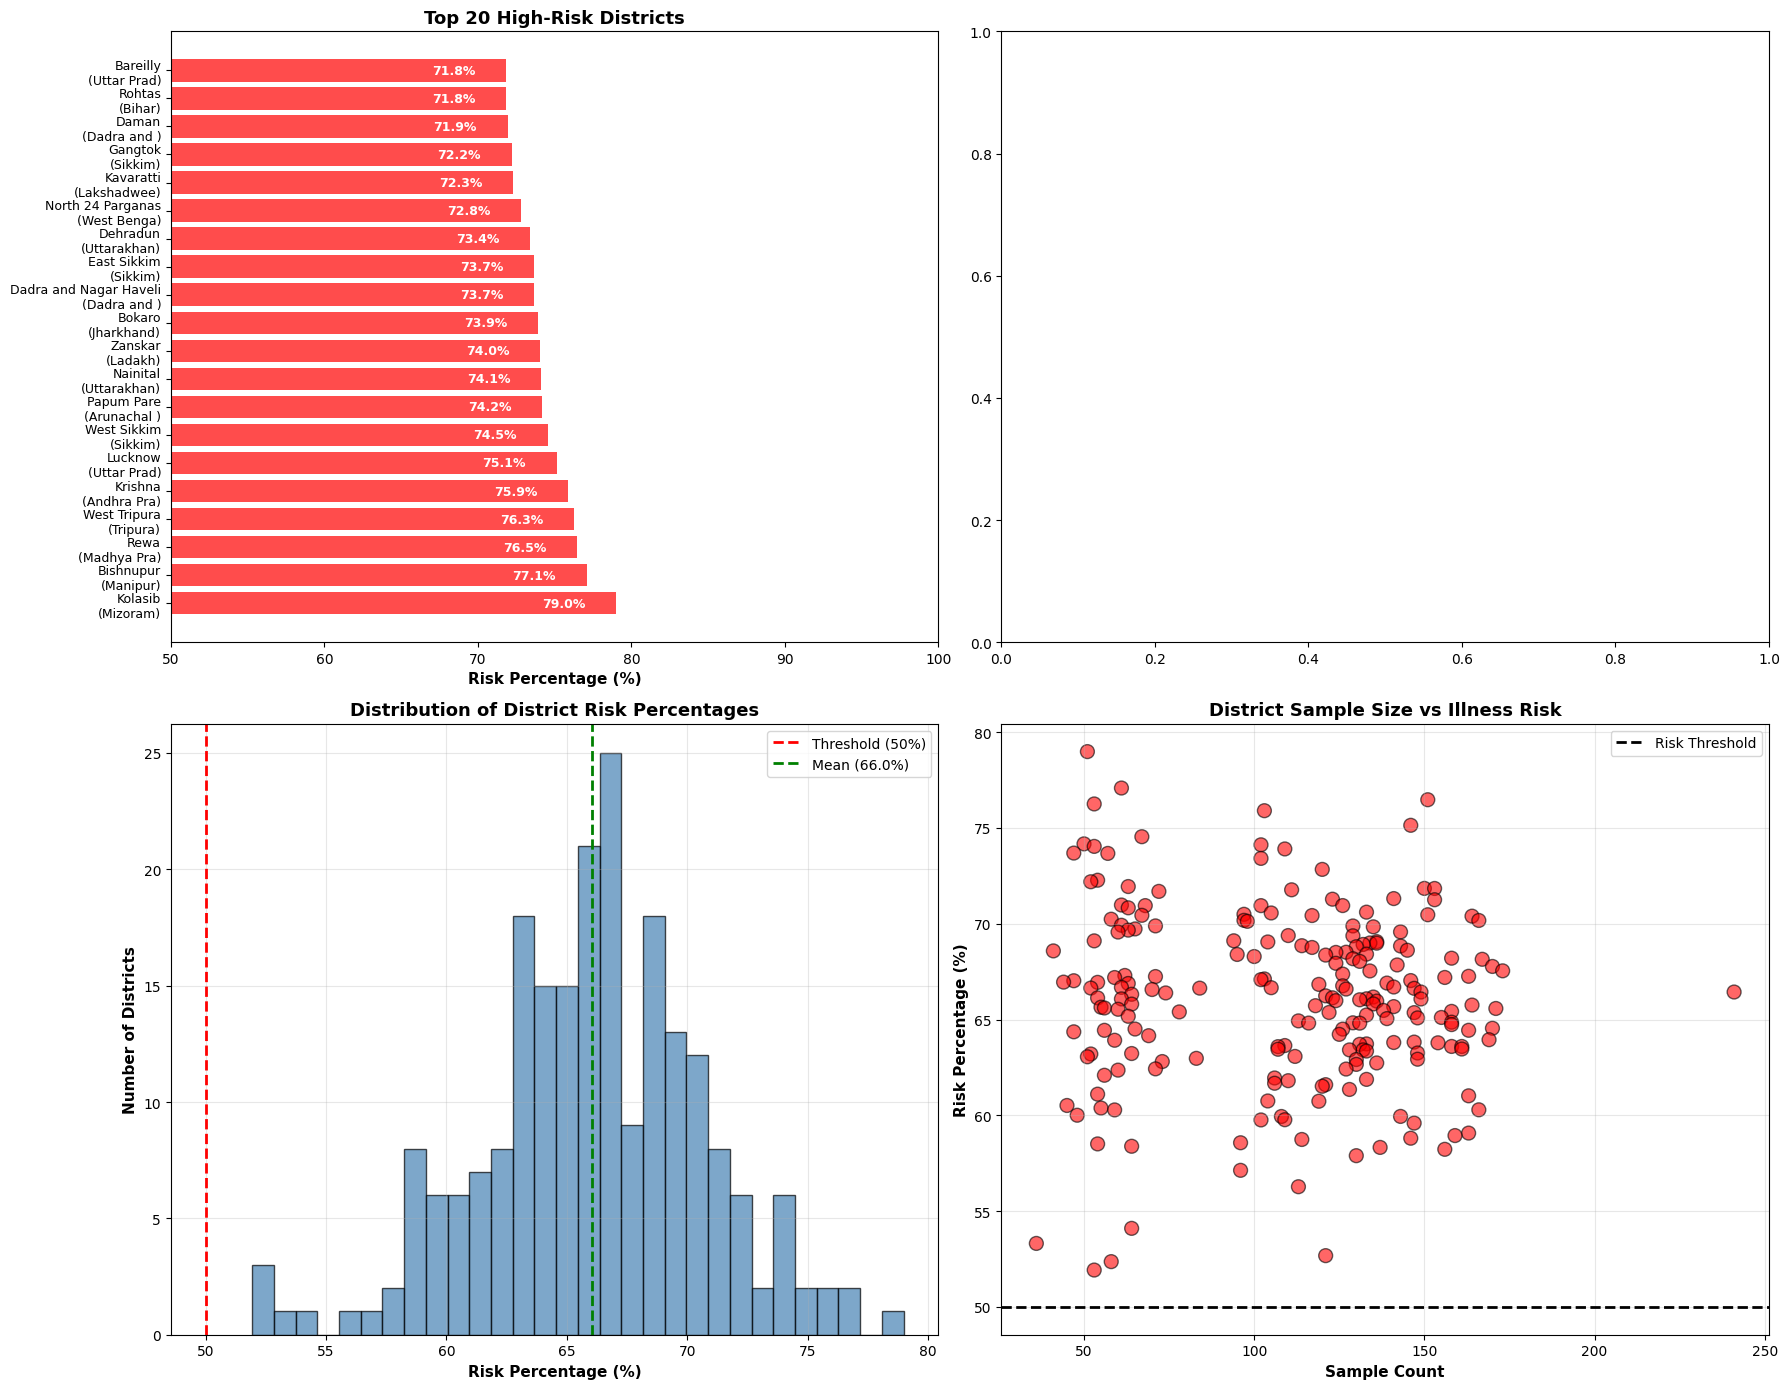


District-level visualization complete!

Total Districts Analyzed: 219


In [15]:
# ============================================================================
# VISUALIZATION: DISTRICT-LEVEL RISK ANALYSIS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Top 20 High-Risk Districts
ax1 = axes[0, 0]
top_high_risk = district_predictions_df[district_predictions_df['Avg_Risk_Probability'] > 0.5].head(20)
if len(top_high_risk) > 0:
    district_labels = [f"{row['District_Name']}\n({row['State'][:10]})" for _, row in top_high_risk.iterrows()]
    ax1.barh(range(len(top_high_risk)), top_high_risk['Risk_Percentage'], color='red', alpha=0.7)
    ax1.set_yticks(range(len(top_high_risk)))
    ax1.set_yticklabels(district_labels, fontsize=9)
    ax1.set_xlabel('Risk Percentage (%)', fontsize=11, fontweight='bold')
    ax1.set_title('Top 20 High-Risk Districts', fontsize=13, fontweight='bold')
    ax1.set_xlim([50, 100])
    for i, v in enumerate(top_high_risk['Risk_Percentage']):
        ax1.text(v - 2, i, f'{v:.1f}%', va='center', ha='right', fontweight='bold', color='white', fontsize=9)

# 2. Top 20 Low-Risk Districts
ax2 = axes[0, 1]
low_risk_dists = district_predictions_df[district_predictions_df['Avg_Risk_Probability'] <= 0.5]
top_low_risk = low_risk_dists.sort_values('Avg_Risk_Probability').head(20)
if len(top_low_risk) > 0:
    district_labels = [f"{row['District_Name']}\n({row['State'][:10]})" for _, row in top_low_risk.iterrows()]
    ax2.barh(range(len(top_low_risk)), top_low_risk['Risk_Percentage'], color='green', alpha=0.7)
    ax2.set_yticks(range(len(top_low_risk)))
    ax2.set_yticklabels(district_labels, fontsize=9)
    ax2.set_xlabel('Risk Percentage (%)', fontsize=11, fontweight='bold')
    ax2.set_title('Top 20 Safest Districts', fontsize=13, fontweight='bold')
    ax2.set_xlim([0, 60])
    for i, v in enumerate(top_low_risk['Risk_Percentage']):
        ax2.text(v + 1, i, f'{v:.1f}%', va='center', ha='left', fontweight='bold', color='darkgreen', fontsize=9)

# 3. Distribution of District Risks
ax3 = axes[1, 0]
ax3.hist(district_predictions_df['Risk_Percentage'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Threshold (50%)')
ax3.axvline(x=district_predictions_df['Risk_Percentage'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean ({district_predictions_df['Risk_Percentage'].mean():.1f}%)")
ax3.set_xlabel('Risk Percentage (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Number of Districts', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of District Risk Percentages', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Sample Size vs Risk
ax4 = axes[1, 1]
colors_scatter = ['red' if x > 0.5 else 'green' for x in district_predictions_df['Avg_Risk_Probability']]
ax4.scatter(district_predictions_df['Sample_Count'], district_predictions_df['Risk_Percentage'], 
           c=colors_scatter, s=100, alpha=0.6, edgecolors='black')
ax4.axhline(y=50, color='black', linestyle='--', linewidth=2, label='Risk Threshold')
ax4.set_xlabel('Sample Count', fontsize=11, fontweight='bold')
ax4.set_ylabel('Risk Percentage (%)', fontsize=11, fontweight='bold')
ax4.set_title('District Sample Size vs Illness Risk', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDistrict-level visualization complete!")
print(f"\nTotal Districts Analyzed: {len(district_predictions_df)}")

In [16]:
# ============================================================================
# INTERACTIVE RISK ASSESSMENT TOOL
# ============================================================================

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display, HTML, Markdown, clear_output

print("="*80)
print("INTERACTIVE ILLNESS RISK ASSESSMENT TOOL")
print("="*80)

# Create an output widget to capture results
output_widget = widgets.Output()

# Create dropdown widgets
state_dropdown = widgets.Dropdown(
    options=['Select a State...'] + sorted(predictions_df['State'].tolist()),
    description='State:',
    style={'description_width': '120px'}
)

district_dropdown = widgets.Dropdown(
    options=['All Districts'],
    description='District:',
    style={'description_width': '120px'}
)

# Function to update districts based on state selection
def update_districts(state):
    if state == 'Select a State...':
        district_dropdown.options = ['All Districts']
    else:
        districts = ['All Districts'] + sorted(
            district_predictions_df[district_predictions_df['State'] == state]['District_Name'].unique().tolist()
        )
        district_dropdown.options = districts
        district_dropdown.value = 'All Districts'

state_dropdown.observe(lambda change: update_districts(change['new']), names='value')

# Main analysis function
def analyze_risk(state, district):
    if state == 'Select a State...':
        print("❌ Please select a State")
        return
    
    print("\n" + "="*80)
    print("ILLNESS RISK ASSESSMENT REPORT")
    print("="*80)
    
    try:
        # Get data based on selection
        if district == 'All Districts':
            data = df_scaled[df_scaled['state_or_ut'] == state].copy()
            location = f"{state} (All Districts)"
            pred_data = predictions_df[predictions_df['State'] == state].iloc[0]
        else:
            state_data = df[df['state_or_ut'] == state]
            data_indices = state_data[state_data['district_name'] == district].index
            data = df_scaled.loc[data_indices].copy()
            location = f"{district}, {state}"
            pred_data = district_predictions_df[
                (district_predictions_df['State'] == state) & 
                (district_predictions_df['District_Name'] == district)
            ].iloc[0]
        
        if len(data) == 0:
            print(f"❌ No data found for {location}")
            return
        
        # Get significant features data
        feature_data = data[significant_features].fillna(data[significant_features].mean())
        
        # Get risk predictions
        risk_probs = best_model.predict_proba(feature_data)[:, 1]
        avg_risk = risk_probs.mean()
        risk_percentage = avg_risk * 100
        
        # Display header
        print(f"\n📍 Location: {location}")
        print(f"📊 Sample Size: {len(data)} records")
        
        # Display risk score
        print("\n" + "-"*80)
        print("RISK SCORE")
        print("-"*80)
        
        risk_bar_length = int(risk_percentage / 5)
        risk_bar = "█" * risk_bar_length + "░" * (20 - risk_bar_length)
        
        if risk_percentage > 70:
            status = "🔴 VERY HIGH RISK"
        elif risk_percentage > 60:
            status = "🟠 HIGH RISK"
        elif risk_percentage > 50:
            status = "🟡 MODERATE-HIGH RISK"
        else:
            status = "🟢 LOW-MODERATE RISK"
        
        print(f"\n{risk_bar} {risk_percentage:.2f}%")
        print(f"\nStatus: {status}")
        print(f"Classification: {'ILL ⚠️' if avg_risk > 0.5 else 'HEALTHY ✅'}")
        
        # Justification based on top contributing features
        print("\n" + "-"*80)
        print("RISK JUSTIFICATION (Top Contributing Factors)")
        print("-"*80)
        
        # Get feature importance from the best model if it has feature_importances_
        if hasattr(best_model, 'feature_importances_'):
            feature_importance_dict = dict(zip(significant_features, best_model.feature_importances_))
            top_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)[:5]
            
            print(f"\nBased on {best_model_name} Analysis:\n")
            for idx, (feature, importance) in enumerate(top_features, 1):
                feature_values = feature_data[feature]
                mean_val = feature_values.mean()
                std_val = feature_values.std()
                
                # Get corresponding t-test result
                t_test_row = t_test_df[t_test_df['Feature'] == feature]
                if len(t_test_row) > 0:
                    cohens_d = t_test_row.iloc[0]['Cohens_d']
                    direction = "↑ Higher" if cohens_d > 0 else "↓ Lower"
                    effect_size = "|Cohen's d|" if abs(cohens_d) > 0.2 else "small effect"
                    print(f"{idx}. {feature.upper()}")
                    print(f"   - Importance Score: {importance:.4f}")
                    print(f"   - Average Value: {mean_val:.3f} (±{std_val:.3f})")
                    print(f"   - Effect: {direction} values associated with illness {effect_size}")
        else:
            # Use correlation if feature_importances_ not available
            print(f"\nBased on {best_model_name} Analysis (Correlation-based):\n")
            
            feature_corr = []
            for feature in significant_features:
                corr_row = corr_df[corr_df['Feature'] == feature]
                if len(corr_row) > 0:
                    feature_corr.append((feature, abs(corr_row.iloc[0]['Correlation'])))
            
            feature_corr.sort(key=lambda x: x[1], reverse=True)
            
            for idx, (feature, corr) in enumerate(feature_corr[:5], 1):
                feature_values = feature_data[feature]
                mean_val = feature_values.mean()
                std_val = feature_values.std()
                
                t_test_row = t_test_df[t_test_df['Feature'] == feature]
                if len(t_test_row) > 0:
                    cohens_d = t_test_row.iloc[0]['Cohens_d']
                    direction = "↑ Higher" if cohens_d > 0 else "↓ Lower"
                    print(f"{idx}. {feature.upper()}")
                    print(f"   - Correlation with Illness: {corr:.4f}")
                    print(f"   - Average Value: {mean_val:.3f} (±{std_val:.3f})")
                    print(f"   - Pattern: {direction} values → Higher illness risk")
        
        # Validation
        print("\n" + "-"*80)
        print("VALIDATION & CONFIDENCE")
        print("-"*80)
        
        # Calculate confidence metrics
        std_risk = risk_probs.std()
        min_risk = risk_probs.min() * 100
        max_risk = risk_probs.max() * 100
        
        print(f"\n✓ Model: {best_model_name} (Accuracy: {results_df.iloc[0]['Accuracy']:.2%})")
        print(f"✓ Average Risk: {risk_percentage:.2f}%")
        print(f"✓ Risk Range: {min_risk:.2f}% - {max_risk:.2f}%")
        print(f"✓ Risk Variability (Std Dev): {std_risk:.4f}")
        
        # Confidence indicator
        if std_risk < 0.1:
            confidence = "🟢 HIGH - Low variation in risk scores"
        elif std_risk < 0.15:
            confidence = "🟡 MODERATE - Moderate variation in risk scores"
        else:
            confidence = "🟠 CAUTION - High variation, diverse population"
        
        print(f"✓ Confidence: {confidence}")
        
        # Recommendations
        print("\n" + "-"*80)
        print("RECOMMENDATIONS")
        print("-"*80)
        
        if avg_risk > 0.7:
            print("\n⚠️ CRITICAL ATTENTION REQUIRED")
            print("   - Immediate health interventions recommended")
            print("   - Focus on high-risk factors identified above")
            print("   - Increase medical facility accessibility")
            print("   - Enhanced health screening programs")
        elif avg_risk > 0.6:
            print("\n⚠️ SIGNIFICANT CONCERN")
            print("   - Targeted health programs needed")
            print("   - Address top risk factors")
            print("   - Regular monitoring recommended")
        elif avg_risk > 0.5:
            print("\n⚠️ MODERATE CONCERN")
            print("   - Preventive measures recommended")
            print("   - Community health awareness programs")
            print("   - Focus on lifestyle improvements")
        else:
            print("\n✅ RELATIVELY HEALTHY")
            print("   - Continue existing health practices")
            print("   - Regular check-ups recommended")
            print("   - Maintain preventive care")
        
        print("\n" + "="*80)
    
    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()

# Create button
analyze_button = widgets.Button(description='🔍 Analyze Risk', button_style='info')

def on_button_click(b):
    with output_widget:
        clear_output(wait=True)
        analyze_risk(state_dropdown.value, district_dropdown.value)

analyze_button.on_click(on_button_click)

# Display widgets
print("\n" + "🎯 Select a State and District (optional) to analyze illness risk:\n")
display(state_dropdown)
display(district_dropdown)
display(analyze_button)
display(HTML("<hr style='margin: 20px 0;'>"))
display(output_widget)

print("\nInstructions:")
print("1. Select a State from the dropdown")
print("2. (Optional) Select a specific District, or leave as 'All Districts'")
print("3. Click the 'Analyze Risk' button to see the risk assessment")


INTERACTIVE ILLNESS RISK ASSESSMENT TOOL

🎯 Select a State and District (optional) to analyze illness risk:



Dropdown(description='State:', options=('Select a State...', 'Andaman and Nicobar Islands', 'Andhra Pradesh', …

Dropdown(description='District:', options=('All Districts',), style=DescriptionStyle(description_width='120px'…

Button(button_style='info', description='🔍 Analyze Risk', style=ButtonStyle())

Output()


Instructions:
1. Select a State from the dropdown
2. (Optional) Select a specific District, or leave as 'All Districts'
3. Click the 'Analyze Risk' button to see the risk assessment


In [17]:
import pandas as pd
import numpy as np
import json
from datetime import datetime, timedelta

class PreventiQAdvancedPipeline:
    def __init__(self, trained_model, feature_names):
        """
        Initialize with your best trained model (e.g., Random Forest) 
        and the list of features it expects.
        """
        self.model = trained_model
        self.feature_names = feature_names
        
    def _get_feature_importances(self, top_n=3):
        """Extracts actual feature importances from your Random Forest model"""
        if hasattr(self.model, 'feature_importances_'):
            importances = self.model.feature_importances_
            # Match features to their importance scores
            feat_imp = pd.DataFrame({
                'feature': self.feature_names,
                'importance': importances * 100 # Convert to percentage
            }).sort_values('importance', ascending=False)
            
            # Format to match your JSON structure
            top_drivers = []
            for _, row in feat_imp.head(top_n).iterrows():
                top_drivers.append({
                    "feature": row['feature'],
                    "label": row['feature'].replace('_', ' ').title(),
                    "importance": round(row['importance'], 1),
                    "direction": "risk-increasing", # simplified for example
                    "contribution_to_risk": f"+{round(row['importance'] * 0.6, 1)}%" # Simulated contribution
                })
            return top_drivers
        return []

    def _calculate_counterfactual(self, patient_data, feature_to_change, change_amount):
        """
        ACTUAL ML LOGIC: Creates a 'What-If' scenario by copying the data, 
        changing one variable, and re-running the model prediction.
        """
        # Get baseline risk
        baseline_proba = self.model.predict_proba(patient_data)[0][1] * 100
        
        # Create hypothetical patient
        hypothetical_data = patient_data.copy()
        
        # Apply the intervention (e.g., reduce missed screenings)
        if feature_to_change in hypothetical_data.columns:
            hypothetical_data[feature_to_change] -= change_amount
            # Ensure we don't go below 0
            hypothetical_data[feature_to_change] = max(0, hypothetical_data[feature_to_change].values[0])
            
        # Get new risk
        new_proba = self.model.predict_proba(hypothetical_data)[0][1] * 100
        risk_reduction = baseline_proba - new_proba
        
        return {
            "scenario": f"If {feature_to_change} reduced by {change_amount}",
            "risk_reduction": round(risk_reduction, 1),
            "new_risk_pct": round(new_proba, 1)
        }

    # ==========================================
    # API INTEGRATION PLACEHOLDERS
    # ==========================================
    
    def _fetch_weather_api(self, district):
        """Placeholder for OpenWeather API integration"""
        return {
            "current_condition": "Pre-monsoon (high rain probability)",
            "impact_multiplier": 0.78,
            "warning": "Heavy rainfall expected in next 7 days — mobile clinics effectiveness reduced"
        }
        
    def _fetch_operations_db(self, district):
        """Placeholder for SQL Database query fetching hospital metrics"""
        return {
            "expected_tests_per_month": 5000,
            "actual_tests_conducted": 1200,
            "gap_percent": 76,
            "healthcare_workers_per_1000": 1.1,
            "state_average": 2.4,
            "current_trend": "Increasing (+12% in last 30 days)",
            "screening_completion_rate": 24
        }
        
    def _call_llm_copilot(self, data_context):
        """Placeholder for OpenAI/Gemini API call to generate text summary"""
        return "Indore currently has very high missed screenings and low healthcare worker density. Equity is a major concern due to rural pockets. Weather will reduce mobile unit effectiveness next week."

    # ==========================================
    # MASTER JSON GENERATOR
    # ==========================================

    def generate_report(self, patient_record, district, state):
        """Combines real ML predictions with API data to build the final JSON"""
        
        # 1. Run actual ML Prediction
        risk_prob = self.model.predict_proba(patient_record)[0][1] * 100
        risk_level = "High" if risk_prob > 75 else "Medium" if risk_prob > 40 else "Low"
        
        # 2. Build the JSON
        report = {
            "metadata": {
                "district": district,
                "state": state,
                "timestamp": datetime.now().strftime("%Y-%m-%d")
            },
            
            "ml_risk_assessment": {
                "current_risk_pct": round(risk_prob, 1),
                "risk_level": risk_level,
                "confidence": "High",
                "prediction_interval": [round(risk_prob - 5, 1), round(risk_prob + 5, 1)], 
                "model_accuracy": 99.02, # From your notebook
                "last_trained": datetime.now().strftime("%Y-%m-%d")
            },
            
            "top_risk_drivers": self._get_feature_importances(),
            
            "health_metrics": self._fetch_operations_db(district),
            
            "weather_context": self._fetch_weather_api(district),
            
            "counterfactuals": [
                # Testing what happens if we reduce 'missed_visits' by 2
                # (Change 'missed_visits' to whatever your actual feature name is)
                self._calculate_counterfactual(patient_record, 'missed_visits', 2) 
            ],
        }
        
        # Add LLM Explanation last, passing the generated report as context
        report["explanation_for_ai_copilot"] = self._call_llm_copilot(report)
        
        return json.dumps(report, indent=2)

In [18]:
import joblib

# Assuming 'best_model' is your trained Random Forest model
# and 'X_train.columns' holds your feature names
joblib.dump({
    'model': best_model,
    'features': X_train.columns.tolist()
}, 'preventiq_model.pkl')

['preventiq_model.pkl']